In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('baby.csv')
df.head()

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,1,120,284,27,62,100,False
1,2,113,282,33,64,135,False
2,3,128,279,28,64,115,True
3,4,108,282,23,67,125,True
4,5,136,286,25,62,93,False


In [17]:
# 1. Realiza una exploración de los datos, considerando sus tipos y los descriptivos
# correspondientes.
    # tipos de datis
df.dtypes

Unnamed: 0                   int64
Birth.Weight                 int64
Gestational.Days             int64
Maternal.Age                 int64
Maternal.Height              int64
Maternal.Pregnancy.Weight    int64
Maternal.Smoker               bool
dtype: object

In [18]:
    # valores nulos
df.isnull().sum()

Unnamed: 0                   0
Birth.Weight                 0
Gestational.Days             0
Maternal.Age                 0
Maternal.Height              0
Maternal.Pregnancy.Weight    0
Maternal.Smoker              0
dtype: int64

In [19]:
    # duplicados
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Histograma - Birth.Weigh')

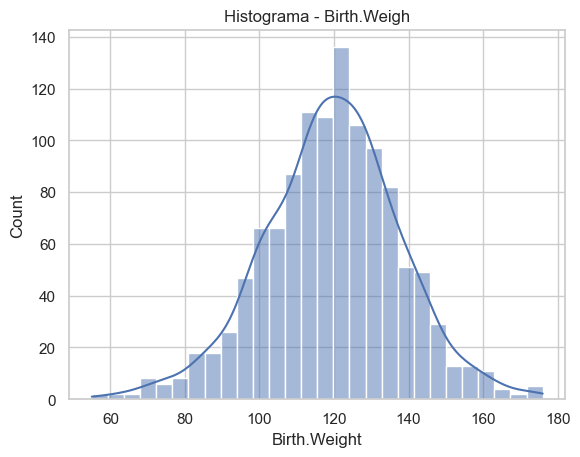

In [84]:
# 2. Considera los pesos de los bebés. ¿Se puede decir que siguen una distribución
# normal? Justifica tu respuesta creando los gráficos y modelos necesarios.
import seaborn as sns
sns.histplot(x=df['Birth.Weight'],data=df, kde=True)
plt.title('Histograma - Birth.Weigh')

In [21]:
"""
Los pesos de los bebes siguen una distribucuion normal puesto que la distribucion se 
encuentra mayor frecuencia al rededor del centro. Ademas en los datos estadisticos 
descriptivos se observa que la media (119.463) es proxima al 50% de la distribucion 
es decir a la mediana (120.000).
"""
df['Birth.Weight'].describe().round(3)

count    1174.000
mean      119.463
std        18.329
min        55.000
25%       108.000
50%       120.000
75%       131.000
max       176.000
Name: Birth.Weight, dtype: float64

In [31]:
# 3. Considerando lo anterior, verifica el modelo de distribución normal de los pesos para
# 5 valores diferentes. Compara con los datos reales.
maths = df['Birth.Weight']
print("La media es:", round(np.mean(maths),2))
print("La varianza es: ", round(np.std(maths), 2))

La media es: 119.46
La varianza es:  18.32


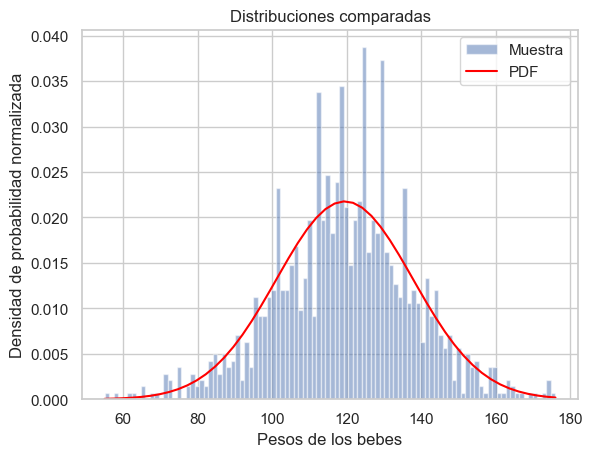

In [85]:
from scipy.stats import norm

#Calculamos la media y la desviación estándar de los datos, además de los valores máximo y mínimo para graficar.
mu=maths.mean()
sigma=maths.std()
minimo=maths.min()
maximo=maths.max()

#Creamos un arreglo de valores equidistantes entre los valores mínimo y máximo, utilizando linspace
x = np.linspace(minimo, maximo)

#Creamos una función, llamada pdf, que calcula el valor de la función de distribución de probabilidad normal, con los parámetros dados
# Notemos que "sigma" funciona como "escala"
pdf = norm.pdf(x, loc=mu, scale=sigma)

# Construimos un histograma de los datos. El parámetro "density=True" va a construir el histograma haciendo que la suma de todas las áreas de las barras sea igual a 1, para que podamos representar las probabilidades
plt.hist(maths, bins=100, density=True, alpha=0.5, label='Muestra')#alpha=0.5 da un 50% de transparencia

plt.plot(x, pdf, color='red', label='PDF') #Graficamos la distribución normal
plt.xlabel('Pesos de los bebes')
plt.ylabel('Densidad de probabilidad normalizada')
plt.title('Distribuciones comparadas')
plt.legend()
plt.show()

In [36]:
import scipy.stats as stats

# 1. Parámetros de tus datos reales (asumiendo df['peso'])
media_peso = df['Birth.Weight'].mean()
desv_estandar_peso = df['Birth.Weight'].std()

# 2. Elegir los 5 valores usando los cuantiles indicados en tu guía
cuantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
valores_evaluar = df['Birth.Weight'].quantile(cuantiles).tolist()

# 3. Crear las listas para almacenar los cálculos
resultados = []

for x in valores_evaluar:
    # P_real: proporción observada directamente en los datos (X <= valor)
    p_real = (df['Birth.Weight'] <= x).mean()
    
    # P_normal: probabilidad estimada por el modelo normal
    p_normal = stats.norm.cdf(x, loc=media_peso, scale=desv_estandar_peso)
    
    # Diferencia entre ambas
    diferencia = abs(p_real - p_normal)
    
    resultados.append({
        'valor': round(x, 2),
        'P_real(X <= valor)': round(p_real, 6),
        'P_normal(X <= valor)': round(p_normal, 6),
        'diferencia': round(diferencia, 6)
    })

# 4. Construir el DataFrame final idéntico al de tu imagen
df_comparacion = pd.DataFrame(resultados)
print(df_comparacion)

   valor  P_real(X <= valor)  P_normal(X <= valor)  diferencia
0   97.0            0.105622              0.110186    0.004564
1  108.0            0.252129              0.265858    0.013729
2  120.0            0.516184              0.511697    0.004487
3  131.0            0.761499              0.735482    0.026018
4  142.0            0.900341              0.890582    0.009759


In [ ]:
"""
La diferencia entre el valor normal y el valor real de los pesos de los bebes es de 
0.004564 gramos para el 10% de la distribucion,
0.013729 granos para el 25% de la distribucion,
0.004487 gramos para el 50% de la distribucion,
0.026018 gramos para el 75% de la distribucion,
0.009759 gramos para el 90% de la distribucion,
Al evaluar el comportamiento de la variable a traves de cinco valores representativos 
(que cubren las zonas bajas, centrales y altas de la muestra), se evidencia numericamente 
que las diferencias entre las proporciones reales y las probabilidades estimadas por 
el modelo normal nunca supera el 2.6%. Al ser dsviaciones tan marginales se confirma de 
manera cuantitatiba que el modelo de distribucion normal con un alto grado de fidelidad 
y precision el comportamiento de los daros reales.
"""

In [87]:
# 4. Compara los pesos de los bebés de madres fumadoras y no fumadoras. ¿Qué
# diferencias existen? Explica y construye los modelos correspondientes
df1=df[['Birth.Weight','Maternal.Smoker']]

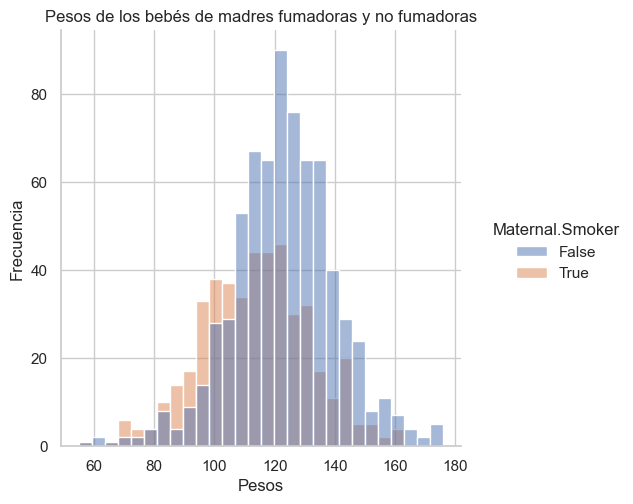

In [82]:
graf1 = sns.displot(data=df1, x='Birth.Weight', hue='Maternal.Smoker',fill=True)
graf1.set(ylabel='Frecuencia',xlabel='Pesos',title='Pesos de los bebés de madres fumadoras y no fumadoras')

In [ ]:
"""¿Qué diferencias existen?
El centro de la distribucion para el grupo de madres no fumadoras se ubica al rededor de 120-125
unidades de peso, mientras que el grupo de madres fumadoras expererimenta un descenso en su 
tendencia central situandose el pico en torno a los 100-115 unidades. Esto sugiere un menor 
peso promedio al nacer asociado al tabaquismo.

En la zona de pesos bajos (menores a 100), el grupo de madres fumadoras muestra una frecuencia 
relativa mas alta, cumulando una porcion visible de sus barras en el extremo izquierdo de la grafica.

En conclusion aunque existe un fuerte solapamiento entre ambos grupos (lo que muestra la variabiidad 
normal), la evidencia visual sugiere que el tabaquismo materno esta correlacionado negativamente con 
el peso del recien nacido, desplazanso la campana hacia valores menores.

"""

In [101]:
# 5. Considerando los dados:
    # 5.1 Calcula la probabilidad de que una madre escogida al azar fume.
df2 = len(df[df['Maternal.Smoker']==True])
p=round(df2/len(df),2)
print(f"La probabilidad de que una madre escogida al azar fume es: {p}")

La probabilidad de que una madre escogida al azar fume es: 0.39


Con 1174 madres y una probabilidad de 0.39, se espera que 457.86 madres sean fumadoras


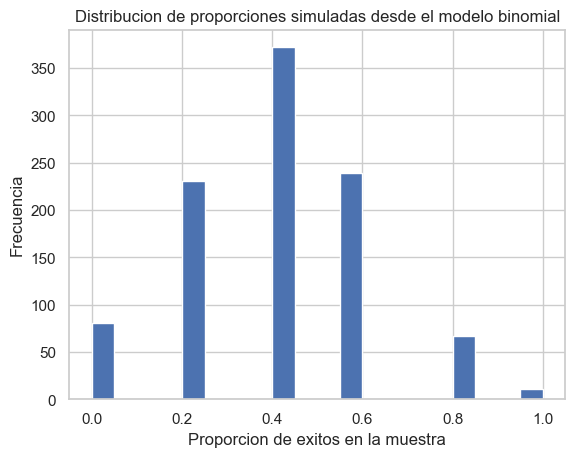

In [158]:
    # 5.2 A partir del valor anterior, construye un modelo de distribución binomial que
    # modele el experimento correspondiente a escoger 5 madres al azar y observar
    # cuántas fuman.

prob_fum = stats.binom(len(df),p)
mu, sigma =prob_fum.stats()
print(f'Con {len(df)} madres y una probabilidad de {p}, se espera que {mu} madres sean fumadoras')

p=p
num_muestras = 1000
tamaño_muestra = 5
# Simulacion desde el modelo binomial
exitos_simulados = np.random.binomial(
    n=tamaño_muestra,
    p=p,
    size=num_muestras
)
proporciones_simuladas = exitos_simulados / tamaño_muestra

plt.hist(proporciones_simuladas,bins=20)
plt.title('Distribucion de proporciones simuladas desde el modelo binomial')
plt.xlabel('Proporcion de exitos en la muestra')
plt.ylabel('Frecuencia')
plt.show()


In [111]:
"""
El experimento de escoger 5 madres al azar con una probabilidad de 0.39 de que fume resulta en la frecuencia observada 
en el grafico. Se observa una tendencia central unimodal al rededor de 330 madres fumadoras cuando la proporcion de exitos 
de la muestra se encuentra en 0.4 lo que significa que existe un 40% de probabilidad de que las madres
fumen de un grupo de 5 madres seleccionadas al azar, es decir 2 de cada 5 madres son fumadoras.
"""

'\nEl experimento de escoger 5 madres al azar con una probabilidad de 0.39 de que fume resulta en la frecuencia observada \nen el grafico. Se observa una tendencia central unimodal al rededor de 330 madres fumadoras cuando la proporcion de exitos \nde la muestra se encuentra en 0.4 lo que significa que existe un 40% de probabilidad de que las madres\nfumen de un grupo de 5 madres seleccionadas al azar, es decir 2 de cada 5 madres son fumadoras.\n'

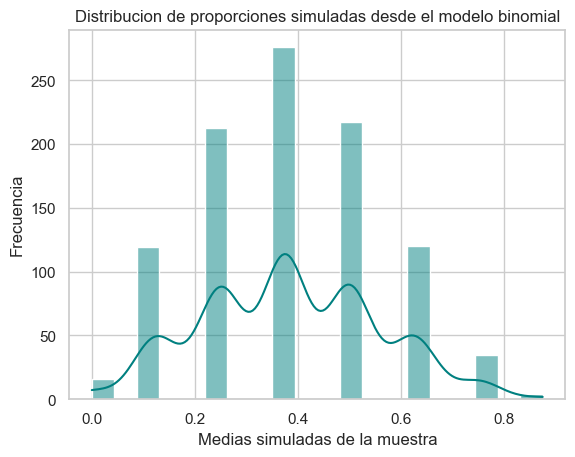

In [183]:
    # 5.3 Utilizando este modelo, simula 1000 muestras de tamaño 8, y calcula sus medias
    # muestrales.
p=p
num_muestras = 1000
tamaño_muestra = 8


# Simulacion desde el modelo binomial
exitos_simulados = np.random.binomial(
    n=tamaño_muestra,
    p=p,
    size=num_muestras,
)

proporciones_simuladas = exitos_simulados / tamaño_muestra

sns.histplot(proporciones_simuladas,
             kde=True,             # Añade la línea de densidad estimada suave
             color='teal',
             bins=20)
plt.title('Distribucion de proporciones simuladas desde el modelo binomial')
plt.xlabel('Medias simuladas de la muestra')
plt.ylabel('Frecuencia')
plt.show()


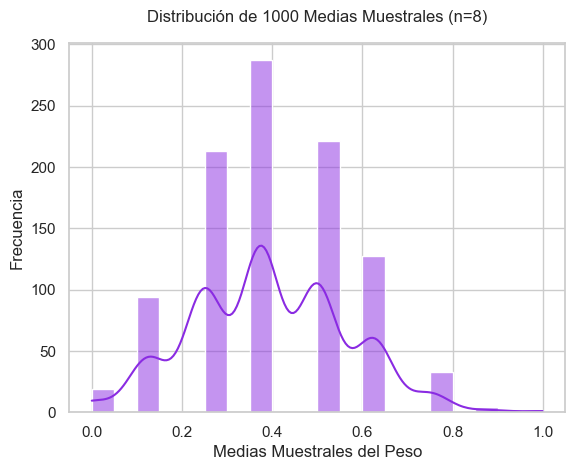

In [180]:
    # 5.4 Utilizando los datos directamente, extrae 1000 muestras de tamaño 8 y calcula
    # sus respectivas medias muestrales.

# 1. Definimos los parámetros del enunciado
n_muestras = 1000
tamano_muestra = 8

# Lista para almacenar las 1000 medias muestrales
medias_muestrales = []

# 2. Bucle para extraer las 1000 muestras y calcular sus medias
for i in range(n_muestras):
    # Extraemos una muestra aleatoria con reemplazo de tamaño 8
    muestra =  df['Maternal.Smoker'].sample(n=tamano_muestra, replace=True)
    # Calculamos la media de esa muestra específica y la guardamos
    medias_muestrales.append(muestra.mean())

# 3. Graficamos
sns.set_theme(style="whitegrid")

sns.histplot(
    medias_muestrales, 
    kde=True,             # Añade la línea de densidad estimada suave
    color="#8a2be2",      # Color violeta
    edgecolor="white"    # Bordes blancos limpios
)

# Personalización de títulos
plt.title('Distribución de 1000 Medias Muestrales (n=8)', fontsize=12, pad=15)
plt.xlabel('Medias Muestrales del Peso')
plt.ylabel('Frecuencia')

plt.show()

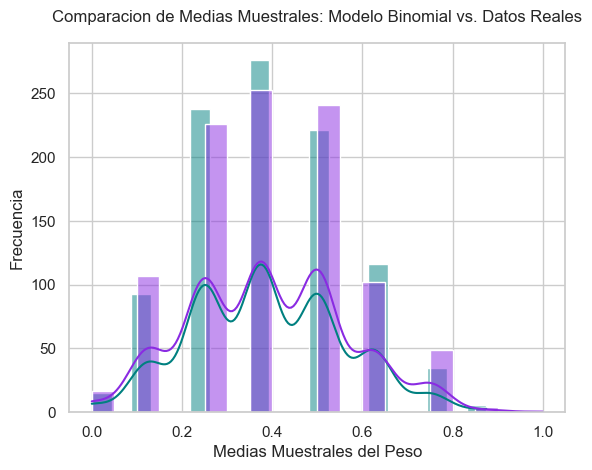

In [184]:
# 5.5 construye un modelo de distribución normal derivado del modelo binomial, y
# grafícalo junto a los anteriores para comparar. Concluye.

    # GRAFICO SIMULADO
p=p
n_muestras = 1000
tamaño_muestra = 8

# Simulacion desde el modelo binomial
exitos_simulados = np.random.binomial(
    n=tamaño_muestra,
    p=p,
    size=n_muestras)
proporciones_simuladas = exitos_simulados / tamaño_muestra

sns.histplot(proporciones_simuladas,
             kde=True,             # Añade la línea de densidad estimada suave
             color='teal',
             bins=20)

    # GRAFICO CON DATOS ORIGINLALES
medias_muestrales = []

# 2. Bucle para extraer las 1000 muestras y calcular sus medias
for i in range(n_muestras):
    # Extraemos una muestra aleatoria con reemplazo de tamaño 8
    muestra =  df['Maternal.Smoker'].sample(n=tamano_muestra, replace=True)
    # Calculamos la media de esa muestra específica y la guardamos
    medias_muestrales.append(muestra.mean())

# 3. Graficamos
sns.set_theme(style="whitegrid")

sns.histplot(
    medias_muestrales, 
    kde=True,             # Añade la línea de densidad estimada suave
    color="#8a2be2",      # Color violeta
    edgecolor="white"    # Bordes blancos limpios
)

# Personalización de títulos
plt.title('Comparacion de Medias Muestrales: Modelo Binomial vs. Datos Reales', fontsize=12, pad=15)
plt.xlabel('Medias Muestrales del Peso')
plt.ylabel('Frecuencia')

plt.show()

In [ ]:
"""
La superposicion de ambos graficos demuestra de forma cuantitativa y visual que el Modelo Binomial es una excelente aproximacion teorica 
para describir el comportamiento de datos reales. La coincidencia en la tendencia central (con un valor mas probable en 0.375) y la minima 
discrepancia en las frecuencias de cada octavo confirman que la probabilidad simulada modela de manera fiel la estructura de la muestra real.
"""